In [ ]:
# Nhập các thư viện cần thiết
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [2]:
# Đọc dữ liệu từ file CSV
data = pd.read_csv('german_credit_data.csv')

# 1 Tiền xử lí dữ liêu
#### 1.1 Tổng quan về dữ liệu và điền dữ liệu thiếu
#### 1.2 Trực quan hóa dữ liệu
#### 1.3 Xử lý ngoại lại 
#### 1.4 Chuẩn hóa dữ liệu và chia dữ liệu train, test

### 1.1 Tổng quan về dữ liệu

In [3]:
# Loại bỏ cột số thứ tự
if 'Unnamed: 0' in data.columns:
    data = data.drop('Unnamed: 0', axis=1)

statistics = data.describe()
# statistics
# print(statistics)
# data.head()     # nhìn sơ bộ về dữ liệu

sex_counts = data['Sex'].value_counts()

# Tính tỷ lệ phần trăm cho cột 'Risk'
risk_percentage = data['Risk'].value_counts(normalize=True) * 100

# Phân tích bảng chéo giữa 'Job' và 'Risk'
crosstab_job_risk = pd.crosstab(data['Job'], data['Risk'])

# In kết quả
print("Tần suất giới tính:\n", sex_counts)
print("\nTỷ lệ phần trăm rủi ro:\n", risk_percentage)
print("\nBảng chéo giữa Job và Risk:\n", crosstab_job_risk)

Tần suất giới tính:
 Sex
male      690
female    310
Name: count, dtype: int64

Tỷ lệ phần trăm rủi ro:
 Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

Bảng chéo giữa Job và Risk:
 Risk  bad  good
Job            
0       7    15
1      56   144
2     186   444
3      51    97


In [4]:
data.shape      # hiểu kích thước bộ dữ liệu

(1000, 10)

In [5]:
data.columns        # hiểu về các cột

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [6]:
data.info()     # thông tin về kểu dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [7]:
# data = data.drop_duplicates() #loại bỏ trùng lặp
# data.info()
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

# Kết hợp kết quả vào một DataFrame mới
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# In kết quả
missing_summary

,Missing Values,Percentage (%)
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,183,18.3
Checking account,394,39.4
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0
Risk,0,0.0


In [8]:
# Xử lý dữ liệu thiếu bằng cách điền bằng mode
for col in ['Saving accounts', 'Checking account']: # little moderate
    mode_value = data[col].mode()[0]
    data[col] = data[col].fillna(mode_value)

In [9]:
# Loại bỏ các hàng trùng lặp sau khi điền dữ liệu thiếu
data = data.drop_duplicates()
data.info()
print("\nSố lượng giá trị thiếu sau khi điền bằng mode:")
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

# Kết hợp kết quả vào một DataFrame mới
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# In kết quả
missing_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB

Số lượng giá trị thiếu sau khi điền bằng mode:


,Missing Values,Percentage (%)
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,0,0.0
Checking account,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0
Risk,0,0.0


In [10]:
# Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)

In [11]:
# Định nghĩa mapping cho cột 'Job'
job_mapping = {
    0: 'unskilled and non-resident',
    1: 'unskilled and resident',
    2: 'skilled',
    3: 'highly skilled'
}

# Sử dụng map để thay thế các giá trị trong cột 'Job'
data['Job'] = data['Job'].map(job_mapping)

In [12]:
# In ra các giá trị unique của mỗi cột
for column in data.columns:
    unique_value = data[column].unique()
    print(column + ": ", end="")
    if len(unique_value)>10:
        print(", ".join(map(str, unique_value[:10])) + str("..."))
    else:
        print(', '.join(map(str, unique_value)))


Age: 67, 22, 49, 45, 53, 35, 61, 28, 25, 24...
Sex: male, female
Job: skilled, unskilled and resident, highly skilled, unskilled and non-resident
Housing: own, free, rent
Saving accounts: little, quite rich, rich, moderate
Checking account: little, moderate, rich
Credit amount: 1169, 5951, 2096, 7882, 4870, 9055, 2835, 6948, 3059, 5234...
Duration: 6, 48, 12, 42, 24, 36, 30, 15, 9, 10...
Purpose: radio/TV, education, furniture/equipment, car, business, domestic appliances, repairs, vacation/others
Risk: good, bad


In [13]:
# các cột dữ liệu định tính: Sex, Housing own, Credit amount, Job, Purpose, Risk, Saving accounts
# các cột dữ liệu định lượng rời rạc: Age, Credit amount, Duration
# các cột dữ liệu bị thiếu: (Saving accounts) (Checking account)

In [14]:
# Định nghĩa các cột categorical
category_features = [
    'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'
]
# Chuyển đổi các cột categorical thành kiểu 'category'
for feature in category_features:
    data[feature] = data[feature].astype('category')

# Chuyển kiểu dữ liệu cột định lượng thành int64
numeric_features = ['Age', 'Credit amount', 'Duration']

for feature in numeric_features:
    data[feature] = data[feature].astype('int64')

In [15]:
le = LabelEncoder()
df_numeric = data.copy()
for col in category_features:
    df_numeric[col] = df_numeric[col].cat.codes

# Thêm biến mục tiêu vào df_numeric
df_numeric['Risk'] = le.fit_transform(data['Risk'])

In [16]:
# Hiển thị thông tin và mô tả dữ liệu sau khi chuyển đổi
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1000 non-null   int64   
 1   Sex               1000 non-null   category
 2   Job               1000 non-null   category
 3   Housing           1000 non-null   category
 4   Saving accounts   1000 non-null   category
 5   Checking account  1000 non-null   category
 6   Credit amount     1000 non-null   int64   
 7   Duration          1000 non-null   int64   
 8   Purpose           1000 non-null   category
 9   Risk              1000 non-null   object  
dtypes: category(6), int64(3), object(1)
memory usage: 38.4+ KB


In [17]:
data.describe()

,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000
std,11.375469,2822.736876,12.058814
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,75.000000,18424.000000,72.000000


In [18]:
data.describe(include='category')

,Sex,Job,Housing,Saving accounts,Checking account,Purpose
count,1000,1000,1000,1000,1000,1000
unique,2,4,3,4,3,8
top,male,skilled,own,little,little,car
freq,690,630,713,786,668,337


## 1.2 Trực quan hóa dữ liệu

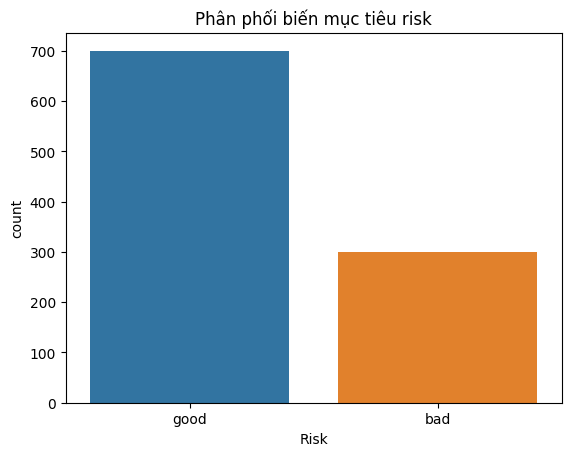

In [19]:
# Vẽ biểu đồ đếm cho biến mục tiêu 'Risk'
sns.countplot(data=data, x='Risk', hue='Risk')
plt.title('Phân phối biến mục tiêu risk')
plt.show()

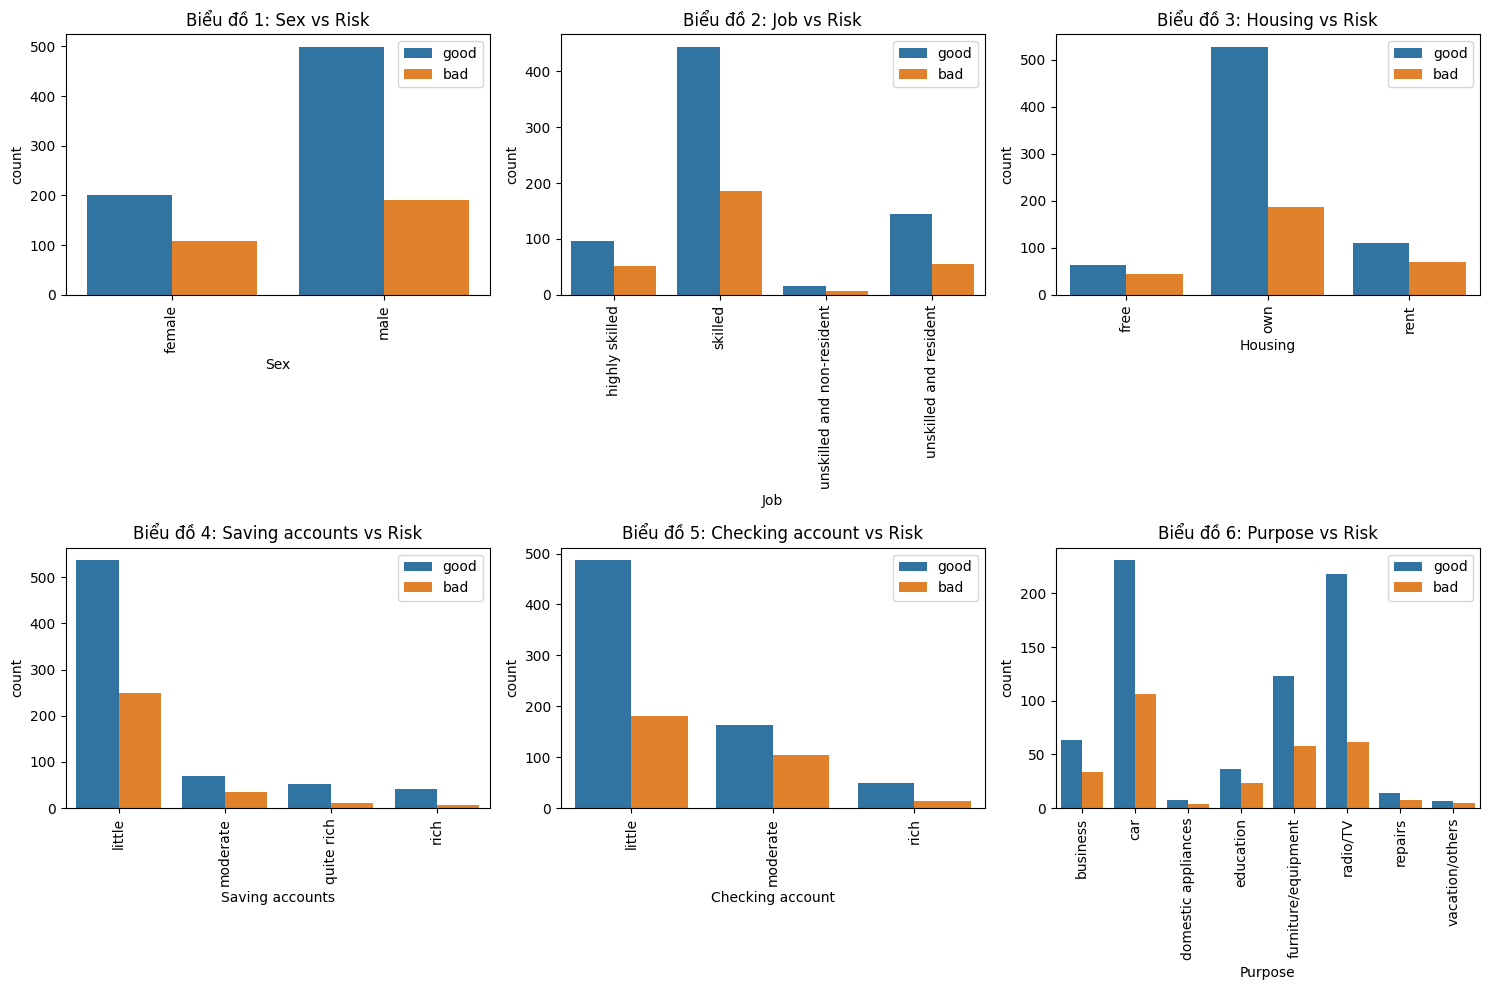

In [20]:
n_row, n_col = 2, 3

fig, ax = plt.subplots(n_row, n_col, figsize=(n_col * 5, n_row * 5))

# Chuyển đổi ax thành một mảng 1 chiều để dễ dàng truy cập
ax = ax.flatten()

for i in range(n_row * n_col):
    if i < len(category_features):
        sns.countplot(data=data, x=category_features[i], hue="Risk", ax=ax[i])
        ax[i].set_title(f"Biểu đồ {i+1}: {category_features[i]} vs Risk")
        # ax[i].legend(title="Risk")
        ax[i].legend(loc="upper right")
        ax[i].tick_params(axis='x', rotation=90)
    else:
        # Nếu không còn feature nào thì không cho hiện
        ax[i].set_visible(False)

plt.tight_layout()  # Đảm bảo không có chồng chéo giữa các tiêu đề
plt.show()


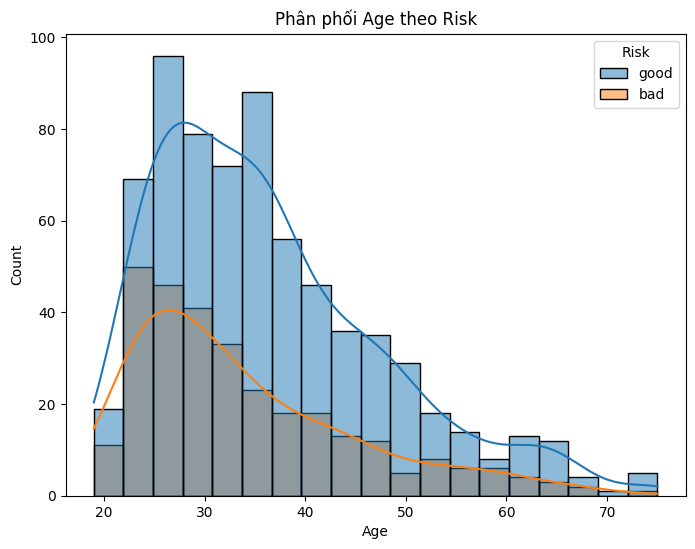

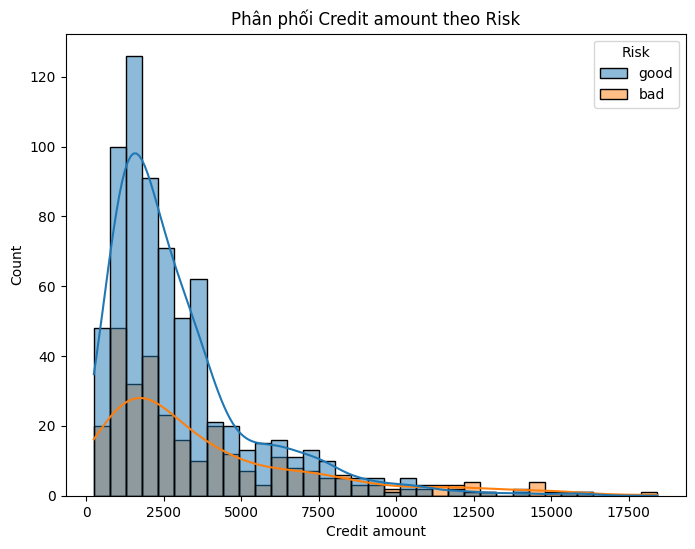

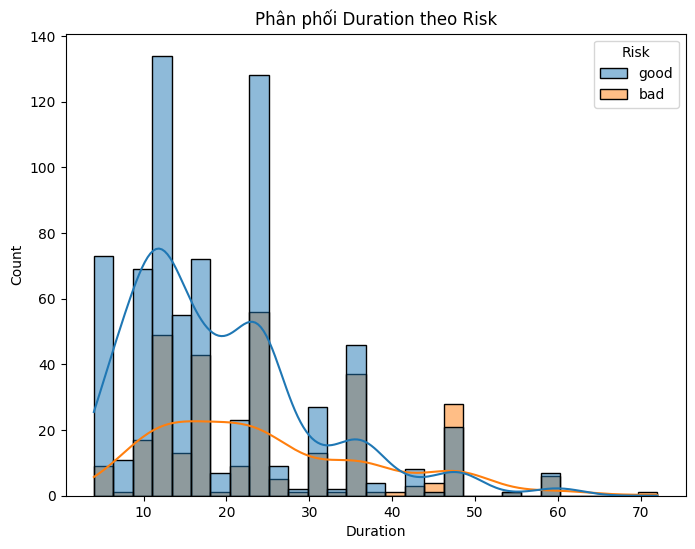

In [21]:
# Vẽ các biểu đồ histogram cho các biến số
for feature in numeric_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=data, x=feature, hue="Risk", kde=True)
    plt.title(f'Phân phối {feature} theo Risk')
    plt.show()

## 1.3 Xử lý ngoại lai

In [22]:
indices_to_drop = []

for feature in numeric_features:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1

    # Xác định giới hạn ngoại lai
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Phát hiện giá trị ngoại lai và lưu chỉ số
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    indices_to_drop.extend(outliers.index)

# Loại bỏ các hàng ngoại lai một lần
data = data.drop(indices_to_drop).reset_index(drop=True)

In [23]:
print("\nThông tin dữ liệu sau khi loại bỏ ngoại lai:")
data.info()


Thông tin dữ liệu sau khi loại bỏ ngoại lai:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               862 non-null    int64   
 1   Sex               862 non-null    category
 2   Job               862 non-null    category
 3   Housing           862 non-null    category
 4   Saving accounts   862 non-null    category
 5   Checking account  862 non-null    category
 6   Credit amount     862 non-null    int64   
 7   Duration          862 non-null    int64   
 8   Purpose           862 non-null    category
 9   Risk              862 non-null    object  
dtypes: category(6), int64(3), object(1)
memory usage: 33.2+ KB


## 1.4 Chuẩn hóa dữ liệu và chia dữ liệu train, test

In [24]:
# Chia dữ liệu thành X và y
y = data['Risk']
X = data.drop(columns='Risk')

In [25]:
print("\nThông tin dữ liệu X:")
X.info()
y.info()


Thông tin dữ liệu X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               862 non-null    int64   
 1   Sex               862 non-null    category
 2   Job               862 non-null    category
 3   Housing           862 non-null    category
 4   Saving accounts   862 non-null    category
 5   Checking account  862 non-null    category
 6   Credit amount     862 non-null    int64   
 7   Duration          862 non-null    int64   
 8   Purpose           862 non-null    category
dtypes: category(6), int64(3)
memory usage: 26.5 KB
<class 'pandas.core.series.Series'>
RangeIndex: 862 entries, 0 to 861
Series name: Risk
Non-Null Count  Dtype 
--------------  ----- 
862 non-null    object
dtypes: object(1)
memory usage: 6.9+ KB


In [26]:
# Định nghĩa các biến categorical và numerical
category_features = [
    'Sex', 'Job', 'Housing', 'Saving accounts', 
    'Checking account', 'Purpose'
]
numeric_features = ['Age', 'Credit amount', 'Duration']

# Tạo transformer
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])  

# Áp dụng transformer
preprocesscer = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, category_features)
])

# Áp dụng quá trình tiền xử lý lên X
X_processed = preprocesscer.fit_transform(X)

print("\nDữ liệu sau khi tiền xử lý:")
X_processed



Dữ liệu sau khi tiền xử lý:


array([[ 1.39408252, -0.26188881, -0.70420151, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.00417365,  3.21807169,  2.75001911, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.78399139,  1.40651949,  0.67748674, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.36050739, -0.47840899, -0.70420151, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.51678757,  0.79725575,  1.36833086, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.32183313, -1.03895569, -0.70420151, ...,  1.        ,
         0.        ,  0.        ]], shape=(862, 27))

In [27]:
# Mã hóa mục tiêu
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nBiến mục tiêu sau khi mã hóa:")
y_encoded


Biến mục tiêu sau khi mã hóa:


array([1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,

In [28]:
# Phân chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, 
    random_state=42, stratify=y_encoded
)

print("\nKích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)

# Lưu lại các transformer nếu cần sử dụng sau này
joblib.dump(preprocesscer, 'preprocessor.pkl')
joblib.dump(le, 'label_encoder.pkl')



Kích thước tập huấn luyện: (689, 27)
Kích thước tập kiểm tra: (173, 27)


['label_encoder.pkl']

# 2. Train model

## 2.1 Logistic Regression

In [29]:
X_train

array([[ 0.51678757, -0.3767648 , -0.35877945, ...,  0.        ,
         0.        ,  0.        ],
       [-0.94537069, -0.19332408, -0.93448289, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.711742  ,  0.02740621, -0.70420151, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.22435592, -0.36654023, -0.70420151, ...,  0.        ,
         0.        ,  0.        ],
       [-0.84789348, -0.72259564, -0.70420151, ...,  0.        ,
         0.        ,  0.        ],
       [-0.26303017, -0.78213869, -0.93448289, ...,  0.        ,
         0.        ,  0.        ]], shape=(689, 27))

In [30]:
# Khởi tạo mô hình hồi quy logistic
logistic_regresion = LogisticRegression()

# Huấn luyện mô hình trên tập huấn luyện
logistic_regresion.fit(X_train, y_train)



LogisticRegression()

In [31]:
# Dự đoán nhãn cho tập kiểm tra
y_pred = logistic_regresion.predict(X_test)

In [32]:
# Độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print("1. Độ chính xác:", accuracy)

# Ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_test, y_pred)
print("2. Ma trận nhầm lẫn:\n", conf_matrix)

# Báo cáo phân loại
class_report = classification_report(y_test, y_pred)
print("3. Báo cáo phân loại:\n", class_report)



1. Độ chính xác: 0.7630057803468208
2. Ma trận nhầm lẫn:
 [[  7  39]
 [  2 125]]
3. Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.78      0.15      0.25        46
           1       0.76      0.98      0.86       127

    accuracy                           0.76       173
   macro avg       0.77      0.57      0.56       173
weighted avg       0.77      0.76      0.70       173



## 2.2 KNN (k-nearest neighbors)

In [33]:
# Khởi tạo mô hình K-Nearest Neighbors với k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Huấn luyện mô hình KNN trên tập huấn luyện
knn.fit(X_train, y_train)

# Dự đoán nhãn cho tập kiểm tra bằng KNN
y_pred_knn = knn.predict(X_test)

# Tính độ chính xác cho KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("1. Độ chính xác của KNN:", accuracy_knn)

# In ma trận nhầm lẫn cho KNN
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("2. Ma trận nhầm lẫn của KNN:\n", conf_matrix_knn)

# In báo cáo phân loại cho KNN
class_report_knn = classification_report(y_test, y_pred_knn)
print("3. Báo cáo phân loại của KNN:\n", class_report_knn)

1. Độ chính xác của KNN: 0.6994219653179191
2. Ma trận nhầm lẫn của KNN:
 [[  7  39]
 [ 13 114]]
3. Báo cáo phân loại của KNN:
               precision    recall  f1-score   support

           0       0.35      0.15      0.21        46
           1       0.75      0.90      0.81       127

    accuracy                           0.70       173
   macro avg       0.55      0.52      0.51       173
weighted avg       0.64      0.70      0.65       173



## 2.3. Decision tree (Gini)

In [34]:
# Khởi tạo mô hình
decision_tree = DecisionTreeClassifier(criterion='gini')

# Huấn luyện mô hình
decision_tree.fit(X_train, y_train)

# Dự đoán nhãn cho tập kiểm tra
y_pred = decision_tree.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred)
print("1. Độ chính xác:", accuracy_dt)

conf_matrix = confusion_matrix(y_test, y_pred)
print("2. Ma trận nhầm lẫn:\n", conf_matrix)

class_report = classification_report(y_test, y_pred)
print("3. Báo cáo phân loại:\n", class_report)

1. Độ chính xác: 0.6473988439306358
2. Ma trận nhầm lẫn:
 [[18 28]
 [33 94]]
3. Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.35      0.39      0.37        46
           1       0.77      0.74      0.76       127

    accuracy                           0.65       173
   macro avg       0.56      0.57      0.56       173
weighted avg       0.66      0.65      0.65       173



## 2.4. Stacking

In [35]:
# Định nghĩa các mô hình cơ sở
base_models = [
    ('decision_tree', decision_tree),
    ('knn', knn),
    ('logistic_regression', logistic_regresion)
]

# Khởi tạo model stacking
stacked_model = StackingClassifier(
    estimators=base_models, final_estimator=LogisticRegression()
)

# Huấn luyện mô hình Stacking trên tập huấn luyện
stacked_model.fit(X_train, y_train)

# Dự đoán nhãn cho tập kiểm tra bằng Stacking Classifier
y_pred_stacking = stacked_model.predict(X_test)

# Tính độ chính xác cho Stacking Classifier
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print("1. Độ chính xác:", accuracy_stacking)

# In ma trận nhầm lẫn và báo cáo phân loại cho Stacking Classifier
conf_matrix_stacking = confusion_matrix(y_test, y_pred_stacking)
print("2. Ma trận nhầm lẫn:\n", conf_matrix_stacking)

class_report_stacking = classification_report(y_test, y_pred_stacking)
print("3. Báo cáo phân loại:\n", class_report_stacking)


1. Độ chính xác: 0.7398843930635838
2. Ma trận nhầm lẫn:
 [[  1  45]
 [  0 127]]
3. Báo cáo phân loại:
               precision    recall  f1-score   support

           0       1.00      0.02      0.04        46
           1       0.74      1.00      0.85       127

    accuracy                           0.74       173
   macro avg       0.87      0.51      0.45       173
weighted avg       0.81      0.74      0.63       173



## Đánh giá mô hình

Log Loss của Logistic Regression: 0.536404687633406
Log Loss của KNN: 2.70542206953585
Log Loss của Decision Tree: 12.709033853966163


Log Loss của Stacking Classifier: 0.5443590832824052

Kết quả các mô hình:
                 Model  Accuracy   Log Loss
0  Logistic Regression  0.763006   0.536405
1                  KNN  0.699422   2.705422
2        Decision Tree  0.647399  12.709034
3  Stacking Classifier  0.739884   0.544359


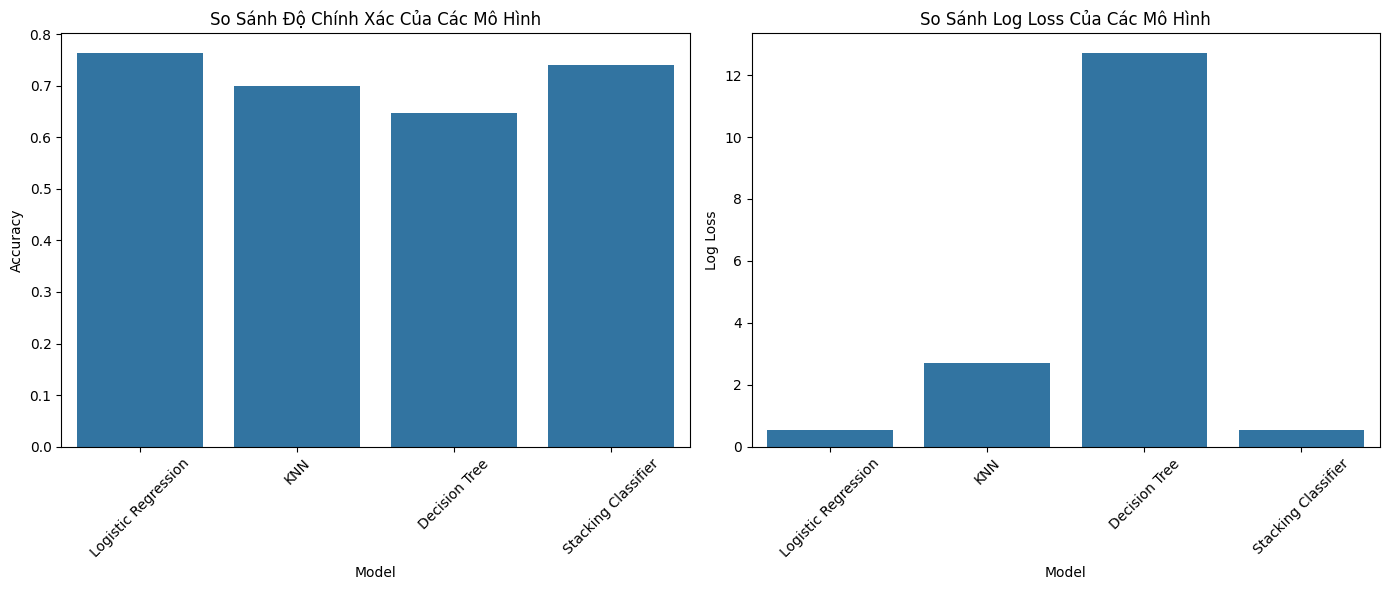

In [36]:
from sklearn.metrics import log_loss

# Logistic Regression
y_prob_lr = logistic_regresion.predict_proba(X_test)
log_loss_lr = log_loss(y_test, y_prob_lr)
print("Log Loss của Logistic Regression:", log_loss_lr)

# KNN
y_prob_knn = knn.predict_proba(X_test)
log_loss_knn = log_loss(y_test, y_prob_knn)
print("Log Loss của KNN:", log_loss_knn)

# Decision Tree
y_prob_dt = decision_tree.predict_proba(X_test)
log_loss_dt = log_loss(y_test, y_prob_dt)
print("Log Loss của Decision Tree:", log_loss_dt)

# Stacking Classifier
y_prob_stacking = stacked_model.predict_proba(X_test)
log_loss_stacking = log_loss(y_test, y_prob_stacking)
print("Log Loss của Stacking Classifier:", log_loss_stacking)

# Tạo DataFrame chứa kết quả
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Stacking Classifier'],
    'Accuracy': [accuracy, accuracy_knn, accuracy_dt, accuracy_stacking],
    'Log Loss': [log_loss_lr, log_loss_knn, log_loss_dt, log_loss_stacking]
})

print("\nKết quả các mô hình:")
print(results)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 6))

# Biểu đồ độ chính xác
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('So Sánh Độ Chính Xác Của Các Mô Hình')
plt.xticks(rotation=45)

# Biểu đồ Log Loss
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Log Loss', data=results)
plt.title('So Sánh Log Loss Của Các Mô Hình')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Luu mô hình

In [37]:
import joblib

# Lưu các mô hình
joblib.dump(logistic_regresion, 'logistic_regression_model.pkl')
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(decision_tree, 'decision_tree_model.pkl')
joblib.dump(stacked_model, 'stacking_model.pkl')

['stacking_model.pkl']

### Giao diện

In [38]:
import tkinter as tk
from tkinter import ttk
import joblib
import pandas as pd
from tkinter import messagebox

# Tải các transformer và mô hình đã lưu
preprocessor = joblib.load('preprocessor.pkl')
label_encoder = joblib.load('label_encoder.pkl')
logistic_model = joblib.load('logistic_regression_model.pkl')
knn_model = joblib.load('knn_model.pkl')
decision_tree_model = joblib.load('decision_tree_model.pkl')
stacking_model = joblib.load('stacking_model.pkl')

# Hàm dự đoán
def predict():
    try:
        # Lấy dữ liệu từ các ô nhập liệu
        Age = float(age_entry.get())
        Credit_amount = float(credit_amount_entry.get())
        Duration = float(duration_entry.get())
        Sex = sex_var.get()
        Job = job_var.get()
        Housing = housing_var.get()
        Saving_accounts = saving_var.get()
        Checking_account = checking_var.get()
        Purpose = purpose_var.get()
        
        # Tạo DataFrame từ dữ liệu nhập
        input_data = {
            'Age': Age,
            'Credit amount': Credit_amount,
            'Duration': Duration,
            'Sex': Sex,
            'Job': Job,
            'Housing': Housing,
            'Saving accounts': Saving_accounts,
            'Checking account': Checking_account,
            'Purpose': Purpose
        }
        
        input_df = pd.DataFrame([input_data])
        
        # Tiền xử lý dữ liệu
        processed_input = preprocessor.transform(input_df)
        
        # Dự đoán bằng các mô hình
        preds = {
            'Logistic Regression': logistic_model.predict(processed_input)[0],
            'KNN': knn_model.predict(processed_input)[0],
            'Decision Tree': decision_tree_model.predict(processed_input)[0],
            'Stacking Classifier': stacking_model.predict(processed_input)[0]
        }
        
        # Giải mã kết quả
        for key in preds:
            preds[key] = label_encoder.inverse_transform([preds[key]])[0]



        good_count = sum(1 for prediction in preds.values() if prediction == 'good')
        bad_count = sum(1 for prediction in preds.values() if prediction == 'bad')
        if (good_count == 2 or bad_count ==2 ): a = preds['Stacking Classifier']
        elif (good_count >= 3):a = 'good'
        elif (bad_count >= 3):a = 'bad'
        predictionz = a
        result_text = ""
        for model, prediction in preds.items():
            result_text += f"{model}: {predictionz}\n"
        
        messagebox.showinfo("Kết Quả Dự Đoán", result_text)
        
    except Exception as e:
        messagebox.showerror("Lỗi", f"Đã xảy ra lỗi: {e}")

# Tạo cửa sổ chính
root = tk.Tk()
root.title("Ứng Dụng Dự Đoán Rủi Ro Tín Dụng")
root.geometry("500x600")

# Tạo các nhãn và ô nhập liệu
frame = ttk.Frame(root, padding="10")
frame.pack(fill=tk.BOTH, expand=True)

# Age
ttk.Label(frame, text="Age:").grid(row=0, column=0, sticky=tk.W, pady=5)
age_entry = ttk.Entry(frame)
age_entry.grid(row=0, column=1, pady=5)

# Credit Amount
ttk.Label(frame, text="Credit Amount:").grid(row=1, column=0, sticky=tk.W, pady=5)
credit_amount_entry = ttk.Entry(frame)
credit_amount_entry.grid(row=1, column=1, pady=5)

# Duration
ttk.Label(frame, text="Duration (months):").grid(row=2, column=0, sticky=tk.W, pady=5)
duration_entry = ttk.Entry(frame)
duration_entry.grid(row=2, column=1, pady=5)

# Sex
ttk.Label(frame, text="Sex:").grid(row=3, column=0, sticky=tk.W, pady=5)
sex_var = tk.StringVar()
sex_combo = ttk.Combobox(frame, textvariable=sex_var, state="readonly")
sex_combo['values'] = ('male', 'female')
sex_combo.grid(row=3, column=1, pady=5)
sex_combo.current(0)

# Job
ttk.Label(frame, text="Job:").grid(row=4, column=0, sticky=tk.W, pady=5)
job_var = tk.StringVar()
job_combo = ttk.Combobox(frame, textvariable=job_var, state="readonly")
job_combo['values'] = (
    'unskilled and non-resident',
    'unskilled and resident',
    'skilled',
    'highly skilled'
)
job_combo.grid(row=4, column=1, pady=5)
job_combo.current(0)

# Housing
ttk.Label(frame, text="Housing:").grid(row=5, column=0, sticky=tk.W, pady=5)
housing_var = tk.StringVar()
housing_combo = ttk.Combobox(frame, textvariable=housing_var, state="readonly")
housing_combo['values'] = ('own', 'rent', 'free')
housing_combo.grid(row=5, column=1, pady=5)
housing_combo.current(0)

# Saving Accounts
ttk.Label(frame, text="Saving Accounts:").grid(row=6, column=0, sticky=tk.W, pady=5)
saving_var = tk.StringVar()
saving_combo = ttk.Combobox(frame, textvariable=saving_var, state="readonly")
saving_combo['values'] = ('little', 'moderate', 'quite rich', 'rich')
saving_combo.grid(row=6, column=1, pady=5)
saving_combo.current(0)

# Checking Account
ttk.Label(frame, text="Checking Account:").grid(row=7, column=0, sticky=tk.W, pady=5)
checking_var = tk.StringVar()
checking_combo = ttk.Combobox(frame, textvariable=checking_var, state="readonly")
checking_combo['values'] = ('little', 'moderate', 'rich')
checking_combo.grid(row=7, column=1, pady=5)
checking_combo.current(0)

# Purpose
ttk.Label(frame, text="Purpose:").grid(row=8, column=0, sticky=tk.W, pady=5)
purpose_var = tk.StringVar()
purpose_combo = ttk.Combobox(frame, textvariable=purpose_var, state="readonly")
purpose_combo['values'] = (
    'radio/TV',
    'education',
    'furniture/equipment',
    'repairs',
    'business',
    'domestic appliances',
    'car',
    'others'
)
purpose_combo.grid(row=8, column=1, pady=5)
purpose_combo.current(0)

# Nút Dự Đoán
predict_button = ttk.Button(frame, text="Dự Đoán", command=predict)
predict_button.grid(row=9, column=0, columnspan=2, pady=20)

# Chạy ứng dụng
root.mainloop()